In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 13.6 MB/s eta 0:00:00


**Imports**

In [ ]:
from google.colab import drive
import zipfile
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

In [ ]:
# torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , Dataset,random_split
from torchmetrics.classification import BinaryAccuracy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.video import r3d_18

**Load data**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_file_path = '/content/drive/MyDrive/Shop DataSet.zip'
extract_directory = '/content'

os.makedirs(extract_directory, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_directory)

In [ ]:
shop_lifters_path="/content/Shop DataSet/shop lifters"
shop_nonlifters_path="/content/Shop DataSet/non shop lifters"

In [ ]:
shop_lifters = [os.path.join(shop_lifters_path,i) for i in os.listdir(shop_lifters_path)]
shop_nonlifters = [os.path.join(shop_nonlifters_path,i) for i in os.listdir(shop_nonlifters_path)]

**EDA on data**

In [ ]:
print(len(shop_lifters))
print(len(shop_nonlifters))

324
531


In [ ]:
def number_frames(video_path):
  cap = cv2.VideoCapture(video_path)
  frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  cap.release()
  return frame_count

In [ ]:
def number_fps(video_path):
  cap = cv2.VideoCapture(video_path)
  fps = int(cap.get(cv2.CAP_PROP_FPS))
  cap.release()
  return fps

In [ ]:
shop_lifters_frames = [
    number_frames(i)
    for i in shop_lifters
]

shop_nonlifters_frames = [
    number_frames(i)
    for i in shop_nonlifters
]
shop_lifters_fps = [
    number_fps(i)
    for i in shop_lifters
]

shop_nonlifters_fps = [
    number_fps(i)
    for i in shop_nonlifters
]

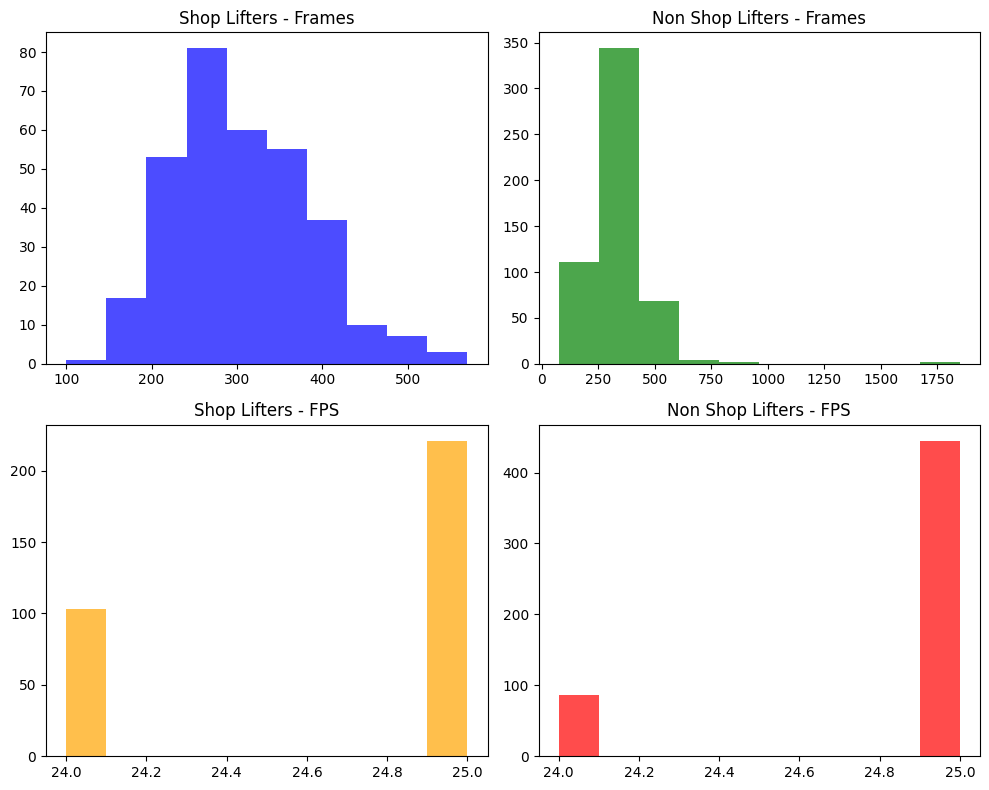

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(shop_lifters_frames, bins=10, color='blue', alpha=0.7)
axes[0, 0].set_title("Shop Lifters - Frames")

axes[0, 1].hist(shop_nonlifters_frames, bins=10, color='green', alpha=0.7)
axes[0, 1].set_title("Non Shop Lifters - Frames")

axes[1, 0].hist(shop_lifters_fps, bins=10, color='orange', alpha=0.7)
axes[1, 0].set_title("Shop Lifters - FPS")

axes[1, 1].hist(shop_nonlifters_fps, bins=10, color='red', alpha=0.7)
axes[1, 1].set_title("Non Shop Lifters - FPS")

plt.tight_layout()
plt.show()

In [ ]:
print(set(shop_lifters_fps))
print(set(shop_nonlifters_fps))

{24, 25}
{24, 25}


**prepare data and splite data into train test**

In [ ]:
class Shop_Dataset(Dataset):
    def __init__(self, shop_lifters, shop_nonlifters, transform=None):
        self.shop_lifters = shop_lifters
        self.shop_nonlifters = shop_nonlifters
        self.transform = transform

    def __len__(self):
        return len(self.shop_lifters) + len(self.shop_nonlifters)

    def __getitem__(self, idx):

        if idx < len(self.shop_lifters):
            video_path = self.shop_lifters[idx]
            label = 1
        else:
            video_path = self.shop_nonlifters[idx - len(self.shop_lifters)]
            label = 0

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        indices = np.linspace(0, total_frames - 1, 16, dtype=int)
        frames = []

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)

        cap.release()

        frames = torch.stack(frames)


        label = torch.tensor(label, dtype=torch.long)

        return frames, label

In [ ]:
# frame size (576, 704, 3)
tranform = transforms.Compose([
    transforms.Resize((112 , 112)),
    transforms.ToTensor()
])

In [ ]:
dataset = Shop_Dataset(shop_lifters, shop_nonlifters, transform=tranform)

In [ ]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model = nn.Sequential(*list(model.children())[:-1])
model.eval().cuda()

dataset_embedd = []

with torch.no_grad():
    for vid, label in dataset:   # assume vid: Tensor [num_frames, 3, H, W]
        # batch process all frames at once
        vid = vid.cuda()

        # Forward pass all frames in one go
        features = model(vid)                # (num_frames, 2048, 1, 1)
        features = features.view(features.size(0), -1)  # (num_frames, 2048)

        dataset_embedd.append(features.cpu())

print(f"Number of videos embedded: {len(dataset_embedd)}")
print(f"Shape of first video embeddings: {dataset_embedd[0][0].shape}")

Number of videos embedded: 855
Shape of first video embeddings: torch.Size([2048])


In [ ]:
video_tensors = []
for vid_embedd in dataset_embedd:
    frames_tensor = torch.stack([f.squeeze() for f in vid_embedd])
    video_tensors.append(frames_tensor)

# take the first video as reference
reference_video = video_tensors[0][0]

# compute cosine similarity per video
similarities = []
for vid_tensor in video_tensors:
    frame_sims = F.cosine_similarity(reference_video, vid_tensor)

    sim = frame_sims.mean().item()
    similarities.append(sim)

for i, sim in enumerate(similarities):
    print(f"Video {i}: Cosine similarity = {sim:.4f}")

Video 0: Cosine similarity = 0.9693
Video 1: Cosine similarity = 0.9330
Video 2: Cosine similarity = 0.8535
Video 3: Cosine similarity = 0.9218
Video 4: Cosine similarity = 0.9486
Video 5: Cosine similarity = 0.9387
Video 6: Cosine similarity = 0.9687
Video 7: Cosine similarity = 0.9503
Video 8: Cosine similarity = 0.9536
Video 9: Cosine similarity = 0.9412
Video 10: Cosine similarity = 0.9581
Video 11: Cosine similarity = 0.9415
Video 12: Cosine similarity = 0.8937
Video 13: Cosine similarity = 0.9235
Video 14: Cosine similarity = 0.9232
Video 15: Cosine similarity = 0.9358
Video 16: Cosine similarity = 0.9353
Video 17: Cosine similarity = 0.9858
Video 18: Cosine similarity = 0.9457
Video 19: Cosine similarity = 0.9665
Video 20: Cosine similarity = 0.9424
Video 21: Cosine similarity = 0.9355
Video 22: Cosine similarity = 0.9061
Video 23: Cosine similarity = 0.9146
Video 24: Cosine similarity = 0.9471
Video 25: Cosine similarity = 0.9437
Video 26: Cosine similarity = 0.9338
Video 27: C

In [ ]:
np.percentile(similarities,90)

np.float64(0.9599928140640259)

In [ ]:
threshold = 0.985
video_vectors = [v for v in video_tensors]
n = len(video_vectors)

keep_indices = []
removed_indices = set()

for i in range(n):
    if i in removed_indices:
        continue
    vi = video_vectors[i]
    keep_indices.append(i)

    for j in range(i + 1, n):
        if j in removed_indices:
            continue

        vj = video_vectors[j]

        frame_sims = F.cosine_similarity(vi, vj, dim=1)
        sim = frame_sims.mean().item()

        if sim > threshold:
            removed_indices.add(j)

cleaned_dataset = [dataset_embedd[i] for i in keep_indices]
removed_items = [dataset_embedd[i] for i in removed_indices]

print(f" Kept {len(cleaned_dataset)} videos, removed {len(removed_items)} duplicates.")

 Kept 489 videos, removed 366 duplicates.


In [ ]:
removed_indices = set(removed_indices)  # O(n), done once
cleaned_dataset = [item for i, item in enumerate(dataset) if i not in removed_indices]


In [ ]:
len(cleaned_dataset)

307

In [ ]:
train_size = int(0.8 * len(cleaned_dataset))
val_size=len(cleaned_dataset)-train_size
train_dataset,val_dataset = random_split(cleaned_dataset, [train_size,val_size])

In [ ]:
print(f"size of train dataset is {len(train_dataset)}")
print(f"size of val dataset is {len(val_dataset)}")

size of train dataset is 391
size of val dataset is 98


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=True)

In [ ]:
batch = next(iter(train_loader))
image, label = batch

print("Images type:", type(image))
print("Images shape:", image.shape)
print("Images dtype:", image.dtype)

print("Label type:", type(label))
print("Label shape:", label.shape)
print("Label value:", label)

Images type: <class 'torch.Tensor'>
Images shape: torch.Size([8, 16, 3, 112, 112])
Images dtype: torch.float32
Label type: <class 'torch.Tensor'>
Label shape: torch.Size([8])
Label value: tensor([1, 1, 1, 1, 0, 0, 1, 0])


**model**

In [ ]:
model = r3d_18(pretrained=True)
model.fc =nn.Linear(model.fc.in_features, 1)

**training loop**

In [ ]:
def fit(num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)  # Move model to the selected device
    criterion = nn.BCEWithLogitsLoss()
    accuracy_metric = BinaryAccuracy().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.000001)
    l1_norm=1e-5
    best_val_loss = float('inf')  # initialize high value

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, epoch_acc = 0.0, 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            images = images.permute(0, 2, 1, 3, 4)
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            preds = model(images)
            loss_value = criterion(preds, labels.unsqueeze(1).float())+l1_norm*sum(p.abs().sum() for p in model.parameters())
            loss_value.backward()
            optimizer.step()

            preds = torch.sigmoid(preds)
            acc = accuracy_metric(preds, labels.unsqueeze(1).float())

            epoch_loss += loss_value.item()
            epoch_acc += acc.item()

        epoch_loss /= len(train_loader)
        epoch_acc /= len(train_loader)

        # ----- VALIDATION -----
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                images = images.permute(0, 2, 1, 3, 4)
                images, labels = images.to(device), labels.to(device)
                preds = model(images)
                loss_value = criterion(preds, labels.unsqueeze(1).float())
                preds = torch.sigmoid(preds)
                acc = accuracy_metric(preds, labels.unsqueeze(1).float())

                val_loss += loss_value.item()
                val_acc += acc.item()

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
        if val_loss < best_val_loss:
          best_val_loss = val_loss
          torch.save(model.state_dict(), "cnn_gru.pth")

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    return model, history

In [ ]:
def visualize_metrics(history):
  plt.plot(history["train_loss"], label="Train Loss")
  plt.plot(history["val_loss"], label="Val Loss")
  plt.legend()
  plt.title("Loss")
  plt.show()


  plt.plot(history["train_acc"], label="Train Acc")
  plt.plot(history["val_acc"], label="Val Acc")
  plt.legend()
  plt.title("Accuracy")
  plt.show()

**Model Fit**

In [ ]:
model,history = fit(num_epochs=50)

Epoch [1/50] | Train Loss: 4.4441, Acc: 0.6265 | Val Loss: 0.5631, Acc: 0.7212


Epoch [2/50] | Train Loss: 4.3652, Acc: 0.8098 | Val Loss: 0.4685, Acc: 0.8846


Epoch [3/50] | Train Loss: 4.3036, Acc: 0.8823 | Val Loss: 0.4056, Acc: 0.9423


Epoch [4/50] | Train Loss: 4.2402, Acc: 0.9133 | Val Loss: 0.3457, Acc: 0.9712


Epoch [5/50] | Train Loss: 4.1732, Acc: 0.9333 | Val Loss: 0.3013, Acc: 0.9712


...

Epoch [46/50] | Train Loss: 3.8184, Acc: 0.9923 | Val Loss: 0.0147, Acc: 0.9904


Epoch [47/50] | Train Loss: 3.7865, Acc: 1.0000 | Val Loss: 0.0275, Acc: 0.9904


Epoch [48/50] | Train Loss: 3.7849, Acc: 1.0000 | Val Loss: 0.0166, Acc: 0.9904


Epoch [49/50] | Train Loss: 3.7924, Acc: 1.0000 | Val Loss: 0.0511, Acc: 0.9615


Epoch [50/50] | Train Loss: 3.7742, Acc: 1.0000 | Val Loss: 0.0171, Acc: 0.9904


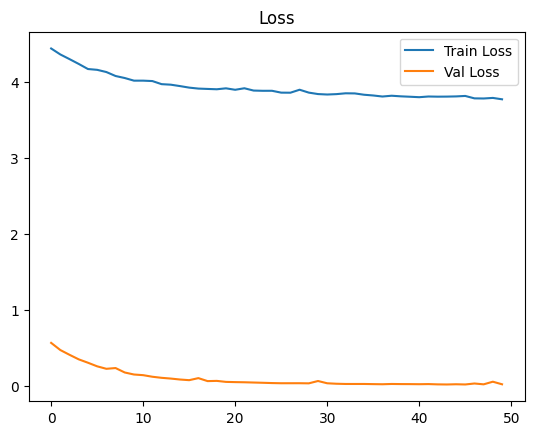

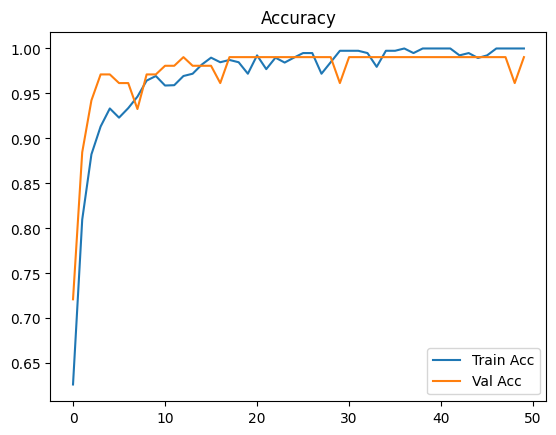

In [ ]:
visualize_metrics(history)